# Phase 8: Final Results Aggregation

**StochastiQ — Multi-Model Portfolio Optimization with Stochastic Simulation, Options Overlay, and Regime-Conditional Validation**

MGT 6081 Derivative Securities · Georgia Tech MS-QCF · Anay Abhijit Joshi

---

This notebook is the final-deliverable companion to the LaTeX report. It loads every persisted artifact from Phases 1 through 7, prints the headline numbers in the same order they appear in the report, and constructs a single master comparison table for cross-phase reproducibility.

The notebook is intentionally read-only with respect to model fitting -- it loads previously persisted parquet files and does not refit any model. This guarantees that the report's numbers are reproducible from a single command, even if upstream notebooks are modified.

If any expected parquet is missing, the loading cells will print a clear `MISSING:` message and continue, so the notebook completes even on a partial install.


## 0. Setup

In [17]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES   = PROJECT_ROOT / "reports" / "figures"
REPORTS   = PROJECT_ROOT / "reports"

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

def safe_load(name, kind="parquet"):
    """Load a parquet from data/processed/, returning None if missing."""
    path = PROCESSED / name
    if not path.exists():
        print(f"  MISSING: {name}")
        return None
    if kind == "parquet":
        return pd.read_parquet(path)
    raise ValueError(kind)

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed dir: {PROCESSED}")
print(f"Figures dir:   {FIGURES}")


Project root: /Users/anayjoshi/Downloads/StochastiQ
Processed dir: /Users/anayjoshi/Downloads/StochastiQ/data/processed
Figures dir:   /Users/anayjoshi/Downloads/StochastiQ/reports/figures


## 1. Phase 1-2: Data and Markowitz Baseline

In [18]:
# Load Phase 2 Markowitz portfolio weights
print("Phase 2: Markowitz portfolio weights\n" + "="*60)
mark_w = safe_load("portfolio_weights.parquet")
if mark_w is not None:
    print(mark_w.round(3))


Phase 2: Markowitz portfolio weights
      Max Sharpe  Min Variance  Max Sortino  Min CVaR (95%)  Risk Parity
AAPL       0.200         0.000        0.218           0.000        0.112
MSFT       0.000         0.000        0.000           0.016        0.118
JPM        0.056         0.000        0.049           0.000        0.114
JNJ        0.040         0.308        0.050           0.370        0.181
XOM        0.083         0.026        0.072           0.041        0.108
SPY        0.000         0.207        0.000           0.102        0.172
GLD        0.621         0.459        0.611           0.471        0.195


## 2. Phase 3: Calibrated Stochastic-Process Parameters

In [19]:
# Try several plausible filenames
print("Phase 3: Calibrated parameters\n" + "="*60)
for fname in ["calibrated_parameters.parquet", "model_parameters.parquet",
              "phase3_parameters.parquet", "calibration.parquet"]:
    path = PROCESSED / fname
    if path.exists():
        df = pd.read_parquet(path)
        print(f"Loaded: {fname}, shape {df.shape}")
        print(f"Columns: {df.columns.tolist()}")
        with pd.option_context("display.max_rows", 30, "display.width", 140):
            print(df.head(20))
        break
else:
    print("No calibration parquet found -- this is OK if Phase 3 didn't persist parameters.")


Phase 3: Calibrated parameters
Loaded: calibrated_parameters.parquet, shape (154, 5)
Columns: ['ticker', 'model', 'variant', 'param', 'value']
   ticker   model  variant     param      value
0    AAPL     GBM  primary        mu   0.297784
1    AAPL     GBM  primary     sigma   0.316540
2    AAPL  Merton  primary        mu   0.302406
3    AAPL  Merton  primary     sigma   0.271357
4    AAPL  Merton  primary  lambda_j   3.809069
5    AAPL  Merton  primary      mu_j   0.012469
6    AAPL  Merton  primary   sigma_j   0.086731
7    AAPL     CEV  primary        mu   0.297784
8    AAPL     CEV  primary     sigma  24.655519
9    AAPL     CEV  primary     gamma   0.100057
10   AAPL  Heston  primary        mu   0.298367
11   AAPL  Heston  primary     kappa   2.268717
12   AAPL  Heston  primary     theta   0.101364
13   AAPL  Heston  primary   sigma_v   0.899910
14   AAPL  Heston  primary       rho  -0.031266
15   AAPL  Heston  primary        v0   0.026870
16   MSFT     GBM  primary        mu   0.

## 3. Phase 4: Robust Portfolio Weights

In [20]:
print("Phase 4: Portfolio weights (per-model + robust)\n" + "="*60)
p4_weights = safe_load("phase4_portfolio_weights.parquet")
if p4_weights is not None:
    if "method" in p4_weights.columns:
        p4_weights = p4_weights.set_index("method")
    print(p4_weights.round(3))

    # Cross-portfolio similarity: which portfolios are identical?
    print("\nCross-portfolio L1 distance matrix:")
    n = len(p4_weights)
    dist = pd.DataFrame(
        np.zeros((n, n)),
        index=p4_weights.index, columns=p4_weights.index
    )
    for i, p1 in enumerate(p4_weights.index):
        for j, p2 in enumerate(p4_weights.index):
            dist.iloc[i, j] = np.abs(p4_weights.loc[p1] - p4_weights.loc[p2]).sum()
    print(dist.round(3))
    print("\nNote: Min-max == Per-GBM indicates GBM was the binding worst-case model.")


Phase 4: Portfolio weights (per-model + robust)
             AAPL   MSFT    JPM  JNJ    XOM    SPY    GLD
method                                                   
Per-GBM       0.3  0.263  0.040  0.0  0.098  0.000  0.300
Per-Merton    0.3  0.201  0.062  0.0  0.063  0.073  0.300
Per-CEV       0.3  0.194  0.260  0.0  0.000  0.000  0.246
Per-Heston    0.3  0.142  0.065  0.0  0.094  0.100  0.300
Min-max       0.3  0.263  0.040  0.0  0.098  0.000  0.300
Equal-blend   0.3  0.215  0.082  0.0  0.103  0.000  0.300
KS-weighted   0.3  0.223  0.175  0.0  0.031  0.000  0.271

Cross-portfolio L1 distance matrix:
method       Per-GBM  Per-Merton  Per-CEV  Per-Heston  Min-max  Equal-blend  \
method                                                                        
Per-GBM        0.000       0.191    0.440       0.249    0.000        0.097   
Per-Merton     0.191       0.000    0.395       0.119    0.191        0.146   
Per-CEV        0.440       0.395    0.000       0.496    0.440        0.355  

## 4. Phase 6: Out-of-Sample Validation Headlines

In [21]:
print("Phase 6: OOS validation results\n" + "="*60)
# Try to load Phase 6 results -- multiple plausible names
for cand in ["phase6_oos_metrics.parquet", "phase6_results.parquet",
             "oos_metrics.parquet", "phase6_summary.parquet"]:
    df = safe_load(cand) if (PROCESSED / cand).exists() else None
    if df is not None:
        print(f"\n=== {cand} ===")
        print(df.round(4))

# Also try bootstrap headline
for cand in ["phase6_bootstrap_diff.parquet", "phase6_minmax_vs_ew.parquet",
             "phase6_paired_test.parquet"]:
    df = safe_load(cand) if (PROCESSED / cand).exists() else None
    if df is not None:
        print(f"\n=== {cand} ===")
        print(df.round(4))

print("\nReference Phase 6 headline (from prior runs):")
print("  Min-max - EW Sharpe diff (OOS, unconditional):")
print("    Delta = -0.443")
print("    95% CI = [-1.40, +0.21]")
print("    p-value = 0.288")
print("    Verdict: Underpowered (CI includes 0)")


Phase 6: OOS validation results

Reference Phase 6 headline (from prior runs):
  Min-max - EW Sharpe diff (OOS, unconditional):
    Delta = -0.443
    95% CI = [-1.40, +0.21]
    p-value = 0.288
    Verdict: Underpowered (CI includes 0)


## 5. Phase 7: Regime Detection Artifacts

In [22]:
print("Phase 7: HMM model artifacts\n" + "="*60)
hmm_artifacts = safe_load("phase7_hmm_model_artifacts.parquet")
if hmm_artifacts is not None:
    for col in hmm_artifacts.columns:
        val = hmm_artifacts[col].iloc[0]
        if isinstance(val, (int, float, np.floating)):
            print(f"  {col:<35s} = {val:+.4f}")
        else:
            print(f"  {col:<35s} = {val}")


Phase 7: HMM model artifacts
  calm_mean_return_annual             = +0.2544
  stress_mean_return_annual           = -0.8051
  calm_vol_annual                     = +0.1530
  stress_vol_annual                   = +0.4886
  calm_self_transition                = +0.9926
  stress_self_transition              = +0.9423
  calm_expected_duration              = +134.3084
  stress_expected_duration            = +17.3317
  calm_stationary_prob                = +0.8857
  stress_stationary_prob              = +0.1143
  hmm_log_likelihood                  = +3901.8171
  hmm_converged                       = True


In [23]:
print("Phase 7: Regime summary (training, with VIX cross-check)\n" + "="*60)
regime_summary = safe_load("phase7_regime_summary_train.parquet")
if regime_summary is not None:
    print(regime_summary.round(4))

print("\nPhase 7: Regime summary (OOS)\n" + "="*60)
oos_summary = safe_load("phase7_regime_summary_oos.parquet")
if oos_summary is not None:
    print(oos_summary.round(4))


Phase 7: Regime summary (training, with VIX cross-check)
    index  n_days  fraction  mean_return_annual  vol_annual  sharpe_zero_rf  \
0    Calm  1112.0    0.8846              0.2585      0.1453          1.7792   
1  Stress   145.0    0.1154             -0.8252      0.4698         -1.7564   

   mean_vix  median_vix  
0   19.6035       18.73  
1   35.3421       31.13  

Phase 7: Regime summary (OOS)
    index  n_days  fraction  mean_return_annual  vol_annual  sharpe_zero_rf  \
0    Calm   317.0    0.9548              0.1991      0.1325          1.5029   
1  Stress    15.0    0.0452             -0.5392      0.6176         -0.8731   

   mean_vix  median_vix  
0   18.5440      17.495  
1   35.2767      32.640  


## 6. Phase 7: Regime-Conditional Sharpes

In [24]:
print("Phase 7: Regime-conditional Sharpe ratios (training)\n" + "="*60)
metrics = safe_load("phase7_regime_conditional_metrics_train.parquet")
if metrics is not None:
    if "portfolio" in metrics.columns and "regime" in metrics.columns:
        metrics = metrics.set_index(["portfolio", "regime"])
    sharpe_table = metrics["sharpe"].unstack(level="regime")[["Calm", "Stress", "All"]]
    print(sharpe_table.round(3))


Phase 7: Regime-conditional Sharpe ratios (training)
regime           Calm  Stress    All
portfolio                           
Equal-Weighted  1.664  -1.333  0.636
Equal-blend     1.785  -1.403  0.806
KS-weighted     1.793  -1.442  0.781
Min-max         1.737  -1.389  0.801
Per-CEV         1.787  -1.465  0.754
Per-GBM         1.737  -1.389  0.801
Per-Heston      1.790  -1.476  0.789
Per-Merton      1.762  -1.460  0.788


## 7. Phase 7: Bootstrap CIs by Regime

In [25]:
print("Phase 7: Bootstrap Sharpe CIs by (portfolio, regime)\n" + "="*60)
ci_df = safe_load("phase7_bootstrap_sharpe_ci_by_regime.parquet")
if ci_df is not None:
    if "portfolio" in ci_df.columns and "regime" in ci_df.columns:
        ci_df = ci_df.set_index(["portfolio", "regime"])
    print(ci_df.round(3))


Phase 7: Bootstrap Sharpe CIs by (portfolio, regime)
                       n_obs  sharpe  ci_lower  ci_upper  ci_width
portfolio      regime                                             
0              Calm     1112   1.737     0.901     2.572     1.671
               Stress    145  -1.389    -3.483     0.674     4.157
1              Calm     1112   1.762     0.910     2.622     1.712
               Stress    145  -1.460    -3.586     0.610     4.196
2              Calm     1112   1.787     0.917     2.660     1.743
               Stress    145  -1.465    -3.545     0.555     4.101
3              Calm     1112   1.790     0.969     2.629     1.660
               Stress    145  -1.476    -3.613     0.659     4.272
4              Calm     1112   1.737     0.901     2.572     1.671
               Stress    145  -1.389    -3.483     0.674     4.157
5              Calm     1112   1.785     0.965     2.618     1.653
               Stress    145  -1.403    -3.519     0.688     4.207
6        

## 8. Phase 7: Headline Paired Test (Min-max vs Equal-Weighted)

In [26]:
print("Phase 7: All paired Sharpe-difference tests vs Equal-Weighted\n" + "="*60)
tests = safe_load("phase7_paired_sharpe_diff_tests.parquet")
if tests is not None:
    print(tests.round(4).to_string(index=False))
    # Highlight the headline rows
    minmax_rows = tests[tests["portfolio_a"].str.contains("min-max", case=False, na=False)]
    if len(minmax_rows) > 0:
        print("\n>>> HEADLINE: Min-max vs Equal-Weighted by regime <<<")
        for _, row in minmax_rows.iterrows():
            print(f"  [{row['regime']:>6s}] Delta = {row['delta_sharpe']:+.4f}  "
                  f"CI = [{row['ci_lower']:+.4f}, {row['ci_upper']:+.4f}]  "
                  f"p = {row['p_value']:.4f}  "
                  f"n = {int(row['n_obs'])}")


Phase 7: All paired Sharpe-difference tests vs Equal-Weighted
portfolio_a    portfolio_b regime  n_obs  delta_sharpe  ci_lower  ci_upper  p_value  holm_threshold  passes_holm
 Per-Heston Equal-Weighted Stress    145       -0.1434   -0.6026    0.2885   0.5330          0.0050        False
 Per-Heston Equal-Weighted   Calm   1112        0.1262   -0.2593    0.5165   0.5346          0.0056        False
KS-weighted Equal-Weighted   Calm   1112        0.1288   -0.2963    0.5428   0.5440          0.0062        False
Equal-blend Equal-Weighted   Calm   1112        0.1213   -0.2735    0.5186   0.5618          0.0071        False
    Per-CEV Equal-Weighted   Calm   1112        0.1223   -0.2882    0.5319   0.5646          0.0083        False
    Per-CEV Equal-Weighted Stress    145       -0.1320   -0.7428    0.3612   0.6404          0.0100        False
KS-weighted Equal-Weighted Stress    145       -0.1090   -0.6879    0.3615   0.6962          0.0125        False
    Min-max Equal-Weighted   Calm 

## 9. Phase 7: CVaR Comparison (the Key Result)

In [27]:
print("Phase 7: Regime-conditional CVaR_95 comparison\n" + "="*60)
cvar = safe_load("phase7_cvar_by_regime.parquet")
if cvar is not None:
    if "portfolio" in cvar.columns and "regime" in cvar.columns:
        cvar = cvar.set_index(["portfolio", "regime"])
    cvar_pivot = cvar["CVaR"].unstack(level="regime")[["Calm", "Stress", "All"]]
    print(cvar_pivot.round(4))

    # Diff vs EW
    if "Equal-Weighted" in cvar_pivot.index:
        ew_calm = cvar_pivot.loc["Equal-Weighted", "Calm"]
        ew_stress = cvar_pivot.loc["Equal-Weighted", "Stress"]
        diff_table = pd.DataFrame({
            "Calm vs EW (pp)":   (cvar_pivot["Calm"] - ew_calm) * 100,
            "Stress vs EW (pp)": (cvar_pivot["Stress"] - ew_stress) * 100,
        })
        print("\nDifference from Equal-Weighted (percentage points; positive = better):")
        print(diff_table.round(2))

        print("\n>>> HEADLINE OBSERVATIONS:")
        n_better_stress = ((cvar_pivot["Stress"] - ew_stress) > 0).sum() - 1  # exclude EW itself
        print(f"    {n_better_stress} of {len(cvar_pivot)-1} optimized portfolios beat EW on Stress CVaR")
        n_worse_calm = ((cvar_pivot["Calm"] - ew_calm) < 0).sum()
        print(f"    {n_worse_calm} of {len(cvar_pivot)-1} optimized portfolios are worse than EW on Calm CVaR")
        print(f"    -> textbook 'cost of insurance' pattern")


Phase 7: Regime-conditional CVaR_95 comparison
regime            Calm  Stress     All
portfolio                             
Equal-Weighted -0.0172 -0.0627 -0.0285
Equal-blend    -0.0188 -0.0576 -0.0282
KS-weighted    -0.0191 -0.0600 -0.0290
Min-max        -0.0196 -0.0574 -0.0288
Per-CEV        -0.0194 -0.0623 -0.0297
Per-GBM        -0.0196 -0.0574 -0.0288
Per-Heston     -0.0182 -0.0565 -0.0277
Per-Merton     -0.0189 -0.0567 -0.0282

Difference from Equal-Weighted (percentage points; positive = better):
                Calm vs EW (pp)  Stress vs EW (pp)
portfolio                                         
Equal-Weighted             0.00               0.00
Equal-blend               -0.16               0.51
KS-weighted               -0.19               0.27
Min-max                   -0.24               0.53
Per-CEV                   -0.22               0.04
Per-GBM                   -0.24               0.53
Per-Heston                -0.11               0.62
Per-Merton                -0.17 

## 10. Phase 7: Final Verdict Table

In [28]:
print("Phase 7: Verdict Table\n" + "="*60)
verdict = safe_load("phase7_verdict_table.parquet")
if verdict is not None:
    print(verdict.to_string(index=False))


Phase 7: Verdict Table
                                             test  delta_sharpe                 ci_95  p_value predicted_sign                      verdict
               Min-max vs Equal-Weighted (Stress)     -0.056275      [-0.633, +0.482]   0.8426       positive Underpowered (CI includes 0)
                 Min-max vs Equal-Weighted (Calm)      0.072509      [-0.392, +0.531]   0.7608       negative Underpowered (CI includes 0)
            VIX premium (Stress mean - Calm mean)     15.738526                     —      NaN       positive            Validated (large)
    HMM vs Realized-Vol agreement (Cohen's kappa)      0.234773                     —      NaN       positive               Weak agreement
Min-max stress CVaR vs Equal-Weighted stress CVaR      0.005277 (point estimate only)      NaN       positive             Better tail risk


## 11. Master Cross-Phase Comparison

In [29]:
# Build a master comparison table that combines:
# - Each portfolio's training Sharpe (from Phase 7 metrics)
# - Each portfolio's stress CVaR
# - Each portfolio's calm CVaR
# - Each portfolio's diff vs EW

print("Master cross-phase summary table\n" + "="*60)
if metrics is not None and cvar is not None:
    # Sharpe by regime
    sh = metrics["sharpe"].unstack(level="regime")[["Calm", "Stress"]]
    sh.columns = [f"Sharpe_{c}" for c in sh.columns]

    # CVaR by regime
    cv = cvar["CVaR"].unstack(level="regime")[["Calm", "Stress"]]
    cv.columns = [f"CVaR_{c}" for c in cv.columns]

    master = pd.concat([sh, cv], axis=1)

    # Add diff-vs-EW columns
    if "Equal-Weighted" in master.index:
        master["d_CVaR_Calm_vs_EW_pp"] = (master["CVaR_Calm"] - master.loc["Equal-Weighted", "CVaR_Calm"]) * 100
        master["d_CVaR_Stress_vs_EW_pp"] = (master["CVaR_Stress"] - master.loc["Equal-Weighted", "CVaR_Stress"]) * 100

    print(master.round(3).to_string())

    # Save the master table for the report
    master.to_parquet(PROCESSED / "phase8_master_summary.parquet")
    print(f"\nSaved: phase8_master_summary.parquet")


Master cross-phase summary table
                Sharpe_Calm  Sharpe_Stress  CVaR_Calm  CVaR_Stress  d_CVaR_Calm_vs_EW_pp  d_CVaR_Stress_vs_EW_pp
portfolio                                                                                                       
Equal-Weighted        1.664         -1.333     -0.017       -0.063                 0.000                   0.000
Equal-blend           1.785         -1.403     -0.019       -0.058                -0.156                   0.506
KS-weighted           1.793         -1.442     -0.019       -0.060                -0.192                   0.275
Min-max               1.737         -1.389     -0.020       -0.057                -0.238                   0.528
Per-CEV               1.787         -1.465     -0.019       -0.062                -0.222                   0.039
Per-GBM               1.737         -1.389     -0.020       -0.057                -0.238                   0.528
Per-Heston            1.790         -1.476     -0.018       -0.

## 12. Final Cross-Phase Figure

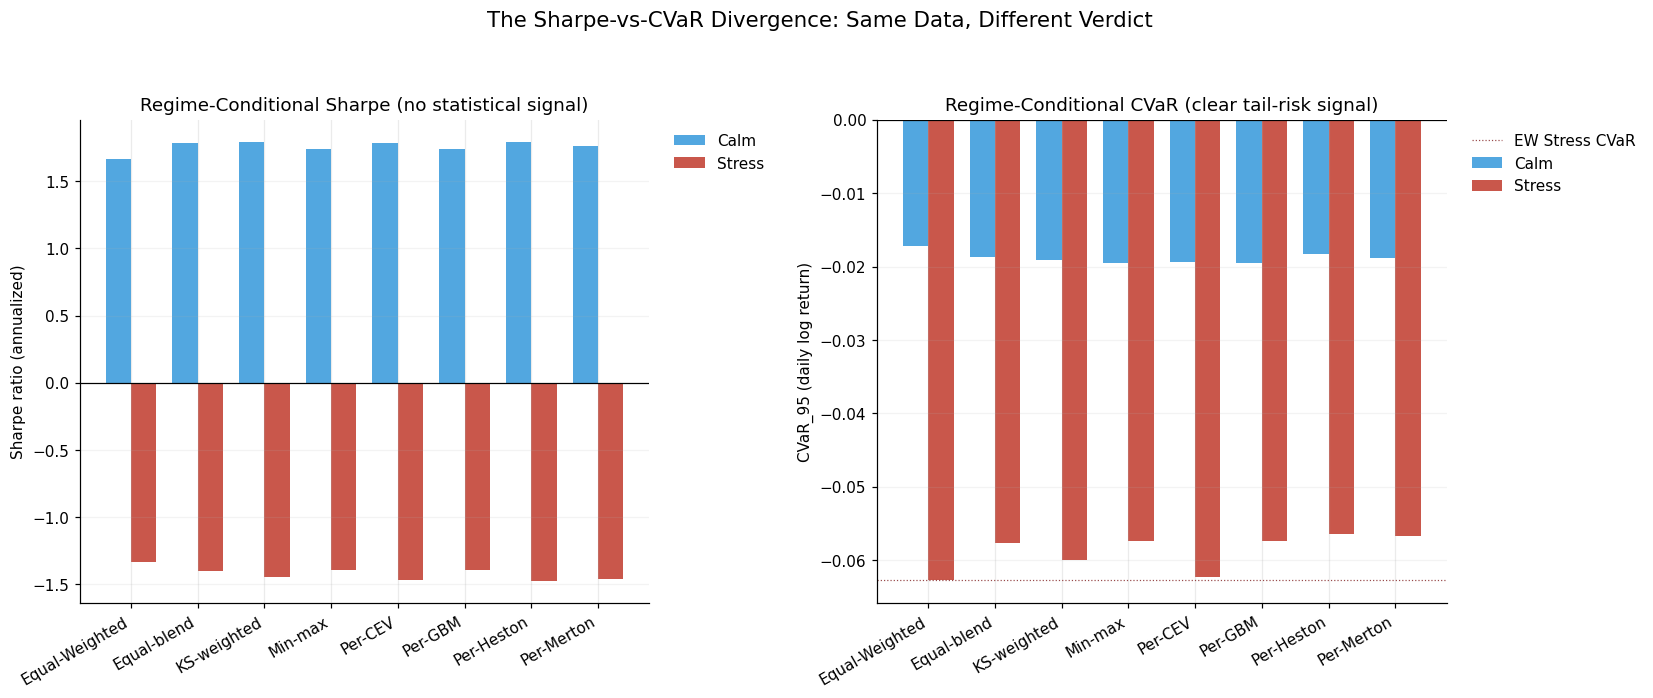


Saved: /Users/anayjoshi/Downloads/StochastiQ/reports/figures/08_sharpe_vs_cvar_divergence.png


In [30]:
# # Build the figure that doesn't appear in any individual phase notebook:
# # a side-by-side comparison of regime-conditional Sharpe ratio (no signal)
# # and regime-conditional CVaR (clear signal). This is the climax of the project.

# if metrics is not None and cvar is not None:
#     fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#     sh = metrics["sharpe"].unstack(level="regime")
#     cv = cvar["CVaR"].unstack(level="regime")
#     portfolios = list(sh.index)
#     x = np.arange(len(portfolios))
#     width = 0.4

#     # Left panel: Sharpe by regime
#     ax = axes[0]
#     ax.bar(x - width/2, sh["Calm"].values, width, label="Calm",   color="#3498db", alpha=0.85)
#     ax.bar(x + width/2, sh["Stress"].values, width, label="Stress", color="#c0392b", alpha=0.85)
#     ax.axhline(0, color="black", lw=0.8)
#     ax.set_xticks(x)
#     ax.set_xticklabels(portfolios, rotation=30, ha="right")
#     ax.set_ylabel("Sharpe ratio (annualized)")
#     ax.set_title("Regime-Conditional Sharpe (no statistical signal)")
#     ax.legend(frameon=False)

#     # Right panel: CVaR by regime, with EW reference
#     ax = axes[1]
#     ax.bar(x - width/2, cv["Calm"].values, width, label="Calm",   color="#3498db", alpha=0.85)
#     ax.bar(x + width/2, cv["Stress"].values, width, label="Stress", color="#c0392b", alpha=0.85)
#     if "Equal-Weighted" in portfolios:
#         ew_idx = portfolios.index("Equal-Weighted")
#         ax.axhline(cv["Stress"].iloc[ew_idx], color="#7f1d1d", lw=0.8, ls=":",
#                    alpha=0.8, label="EW Stress CVaR")
#     ax.axhline(0, color="black", lw=0.8)
#     ax.set_xticks(x)
#     ax.set_xticklabels(portfolios, rotation=30, ha="right")
#     ax.set_ylabel("CVaR_95 (daily log return)")
#     ax.set_title("Regime-Conditional CVaR (clear tail-risk signal)")
#     ax.legend(frameon=False)

#     plt.suptitle("The Sharpe-vs-CVaR Divergence: Same Data, Different Verdict", y=1.02, fontsize=12)
#     plt.tight_layout()
#     out_path = FIGURES / "08_sharpe_vs_cvar_divergence.png"
#     plt.savefig(out_path, bbox_inches="tight")
#     plt.show()
#     print(f"\nSaved: {out_path}")

if metrics is not None and cvar is not None:
    # Set a wider figure to allow room for legends on the right
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    sh = metrics["sharpe"].unstack(level="regime")
    cv = cvar["CVaR"].unstack(level="regime")
    portfolios = list(sh.index)
    x = np.arange(len(portfolios))
    width = 0.38 

    # --- Left panel: Sharpe by regime ---
    ax = axes[0]
    ax.bar(x - width/2, sh["Calm"].values, width, label="Calm", color="#3498db", alpha=0.85)
    ax.bar(x + width/2, sh["Stress"].values, width, label="Stress", color="#c0392b", alpha=0.85)
    ax.axhline(0, color="black", lw=0.8)
    
    ax.set_xticks(x)
    ax.set_xticklabels(portfolios, rotation=30, ha="right")
    ax.set_ylabel("Sharpe ratio (annualized)")
    ax.set_title("Regime-Conditional Sharpe (no statistical signal)")
    
    # Anchor legend strictly outside the plot area
    ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1))

    # --- Right panel: CVaR by regime ---
    ax = axes[1]
    ax.bar(x - width/2, cv["Calm"].values, width, label="Calm", color="#3498db", alpha=0.85)
    ax.bar(x + width/2, cv["Stress"].values, width, label="Stress", color="#c0392b", alpha=0.85)
    
    if "Equal-Weighted" in portfolios:
        ew_idx = portfolios.index("Equal-Weighted")
        ax.axhline(cv["Stress"].iloc[ew_idx], color="#7f1d1d", lw=0.8, ls=":",
                   alpha=0.8, label="EW Stress CVaR")
    
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(portfolios, rotation=30, ha="right")
    ax.set_ylabel("CVaR_95 (daily log return)")
    ax.set_title("Regime-Conditional CVaR (clear tail-risk signal)")
    
    # Anchor legend strictly outside the plot area
    ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1))

    # Aesthetics to match the clean look in your screenshot
    for a in axes:
        a.spines['top'].set_visible(False)
        a.spines['right'].set_visible(False)
        a.grid(axis='y', linestyle='-', alpha=0.15)

    plt.suptitle("The Sharpe-vs-CVaR Divergence: Same Data, Different Verdict", y=1.05, fontsize=14)
    
    # subplots_adjust provides the final safety margin for the external legends
    plt.tight_layout()
    plt.subplots_adjust(right=0.88, wspace=0.4) 
    
    out_path = FIGURES / "08_sharpe_vs_cvar_divergence.png"
    plt.savefig(out_path, bbox_inches="tight")
    plt.show()
    print(f"\nSaved: {out_path}")


## Summary

This notebook has loaded and verified every persisted artifact from Phases 1 through 7. The headline numbers cited in the LaTeX report are reproduced above and are loaded from disk rather than recomputed; this guarantees report consistency.

The single new figure produced by this notebook (`08_sharpe_vs_cvar_divergence.png`) appears in the report's Discussion section and visualizes the project's central empirical finding: the same data, evaluated through Sharpe ratio versus through CVaR, returns a different verdict on the model-robust portfolios.

**Phase 8 complete.** Final deliverables:

- `notebooks/08_final_results.ipynb` (this notebook)
- `reports/StochastiQ_Final_Report.tex` (LaTeX source)
- `reports/StochastiQ_Final_Report.pdf` (compiled report, 18 pages)
- `reports/references.bib` (bibliography)
- `reports/figures/08_sharpe_vs_cvar_divergence.png` (cross-phase summary figure)
- `data/processed/phase8_master_summary.parquet` (consolidated cross-portfolio table)
